In [ ]:
import marimo as mo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform
from scipy.integrate import quad
import torch
import torch.distributions as D

## 1.1 Monte Carlo Integration

### (a)

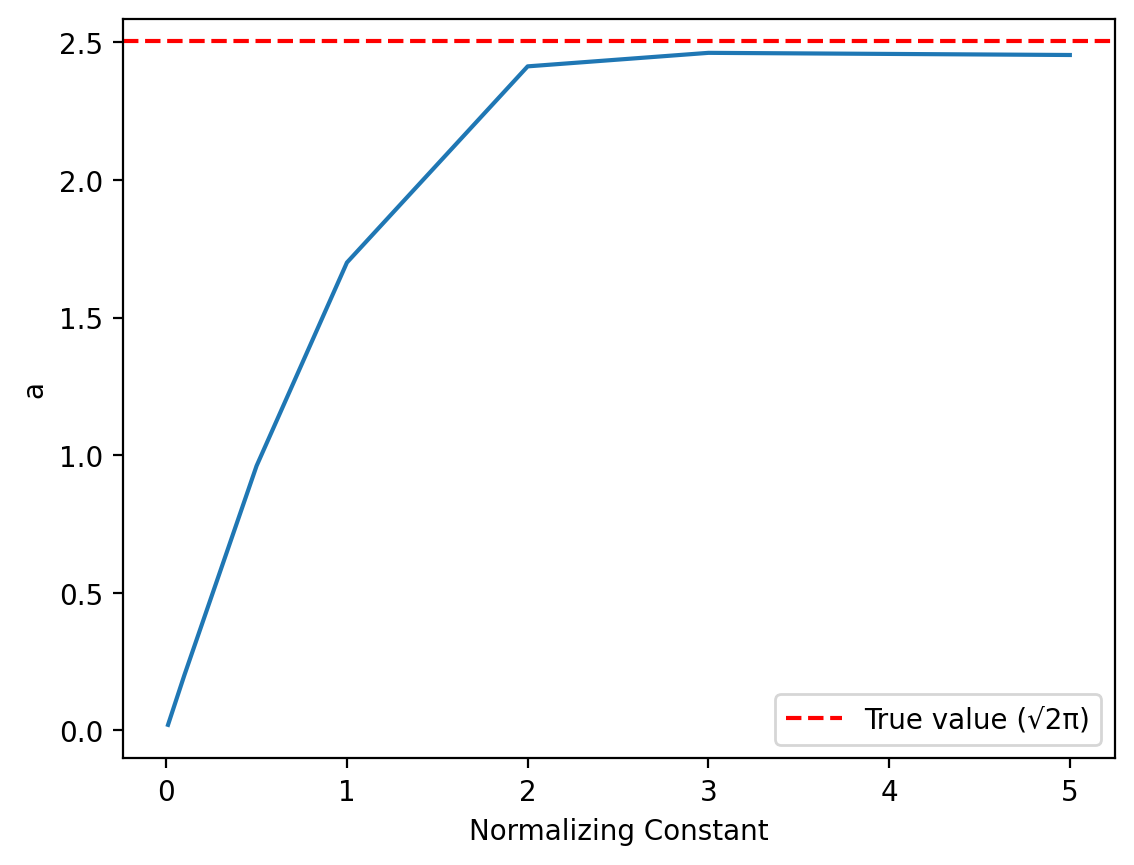

In [ ]:
a_list = [0.01, 0.02, 0.05, 0.1, 0.5, 1, 2, 3, 5]
N = 1000

results_a = []
for _a in a_list:
    samples_a = uniform.rvs(size=N) * (2 * _a) - _a

    f_values = np.exp(-samples_a**2 / 2)

    constant_a = (2 * _a / N) * f_values.sum()

    results_a.append({
        'a': _a,
        'constant': constant_a
    })

results_a = pd.DataFrame(results_a)

# Chart
sns.lineplot(results_a, x='a', y='constant')
plt.axhline(y=np.sqrt(2 * np.pi), color='r', linestyle='--', label='True value (√2π)')
plt.xlabel("Normalizing Constant")
plt.ylabel("a")
plt.legend()
plt.show()

### (b)

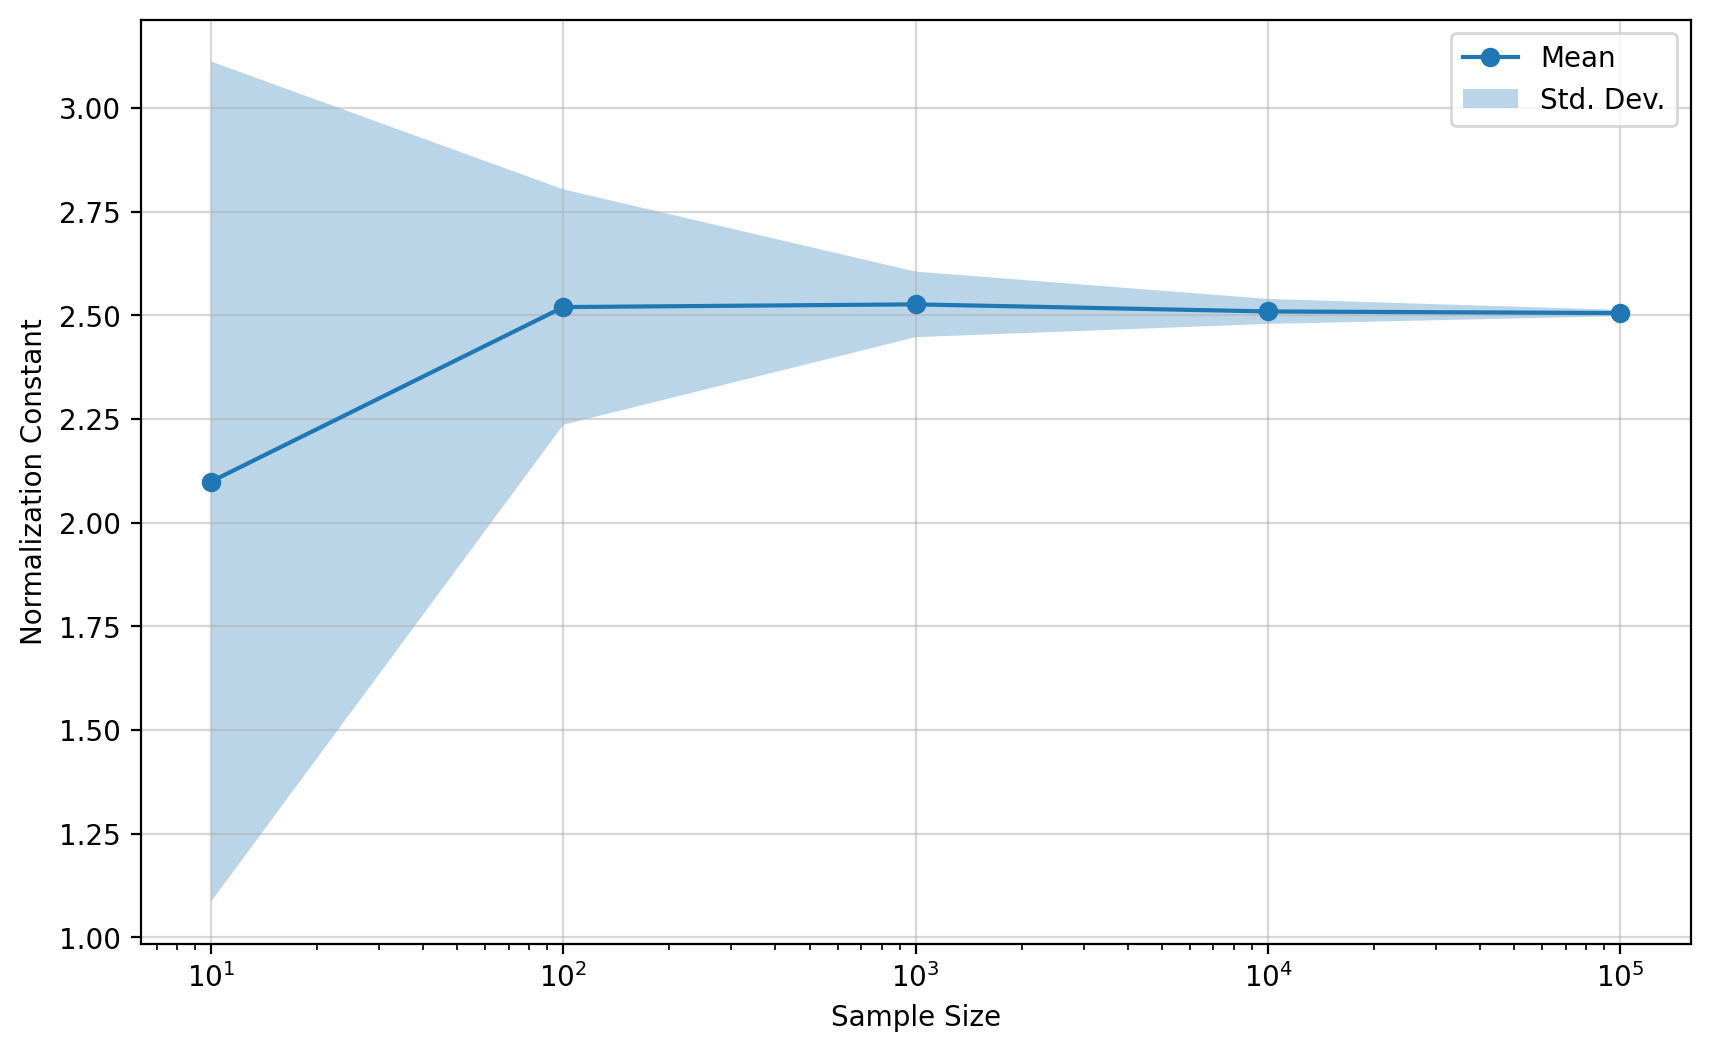

In [ ]:
sample_size_list = [1e1, 1e2, 1e3, 1e4, 1e5]
b_a = 4

def experiment_b(N: int, a: int) -> float:
    samples_a = uniform.rvs(size=N) * (2 * a) - a
    f_values = np.exp(-samples_a**2 / 2)
    constant_a = (2 * a / N) * f_values.sum()
    return constant_a

results_b = []
for sample_size in sample_size_list:
    constants = []
    for _ in range(10):
        constant = experiment_b(N=int(sample_size), a=b_a)
        constants.append(constant)

    results_b.append({
        'sample_size': sample_size,
        'mean': np.mean(constants),
        'stdev': np.std(constants)
    })

results_b = pd.DataFrame(results_b)

# Chart
plt.figure(figsize=(10, 6))
plt.plot(results_b['sample_size'], results_b['mean'], 'o-', label='Mean')
plt.fill_between(
    x=results_b['sample_size'], 
    y1=results_b['mean'] - results_b['stdev'], 
    y2=results_b['mean'] + results_b['stdev'], 
    alpha=0.3, 
    label="Std. Dev."
)
plt.xscale('log')
plt.xlabel('Sample Size')
plt.ylabel('Normalization Constant')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

### (c)

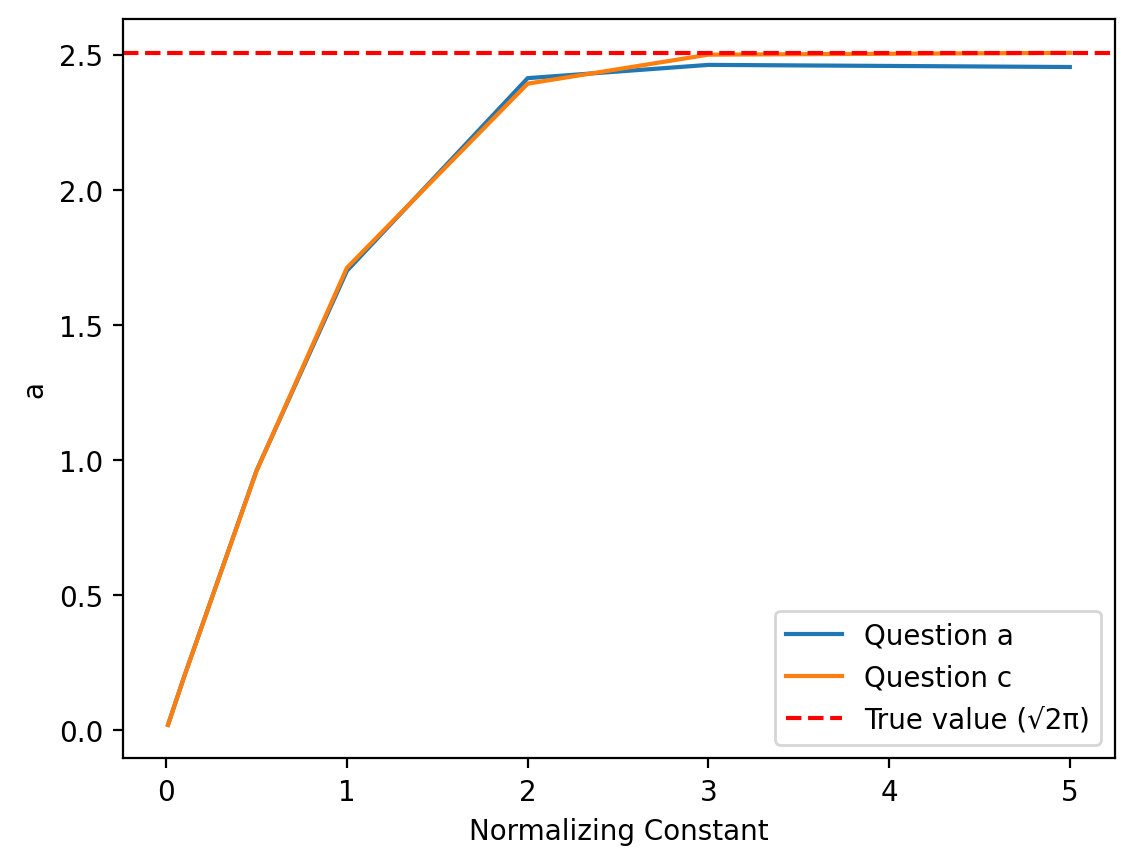

In [ ]:
def f(x: float) -> float:
    return np.exp(x ** 2 * (-.5))

results_c = []
for _a in a_list:
    constant_c, _ = quad(f, -_a, _a)
    results_c.append({
        'a': _a,
        'constant': constant_c
    })

results_c = pd.DataFrame(results_c)

results_a['question'] = 'Question a'
results_c['question'] = 'Question c'

results_all = pd.concat([results_a, results_c])

sns.lineplot(results_all, x='a', y='constant', hue='question')
plt.axhline(y=np.sqrt(2 * np.pi), color='r', linestyle='--', label='True value (√2π)')
plt.xlabel("Normalizing Constant")
plt.ylabel("a")
plt.legend()
plt.show()

## 1.2 Inverse CDF Sampling

### (a)

$F(x; x_0, \gamma) = \frac{1}{\pi} \arctan\left(\frac{x - x_0}{\gamma}\right) + \frac{1}{2}$

$u = \frac{1}{\pi} \arctan\left(\frac{x - x_0}{\gamma}\right) + \frac{1}{2}$

$u - \frac{1}{2} = \frac{1}{\pi} \arctan\left(\frac{x - x_0}{\gamma}\right)$

$\pi\left(u - \frac{1}{2}\right) = \arctan\left(\frac{x - x_0}{\gamma}\right)$

$\tan\left[\pi\left(u - \frac{1}{2}\right)\right] = \frac{x - x_0}{\gamma}$

$x - x_0 = \gamma \tan\left[\pi\left(u - \frac{1}{2}\right)\right]$

$F^{-1}(u) = x_0 + \gamma \tan\left[\pi\left(u - \frac{1}{2}\right)\right]$

### (b)

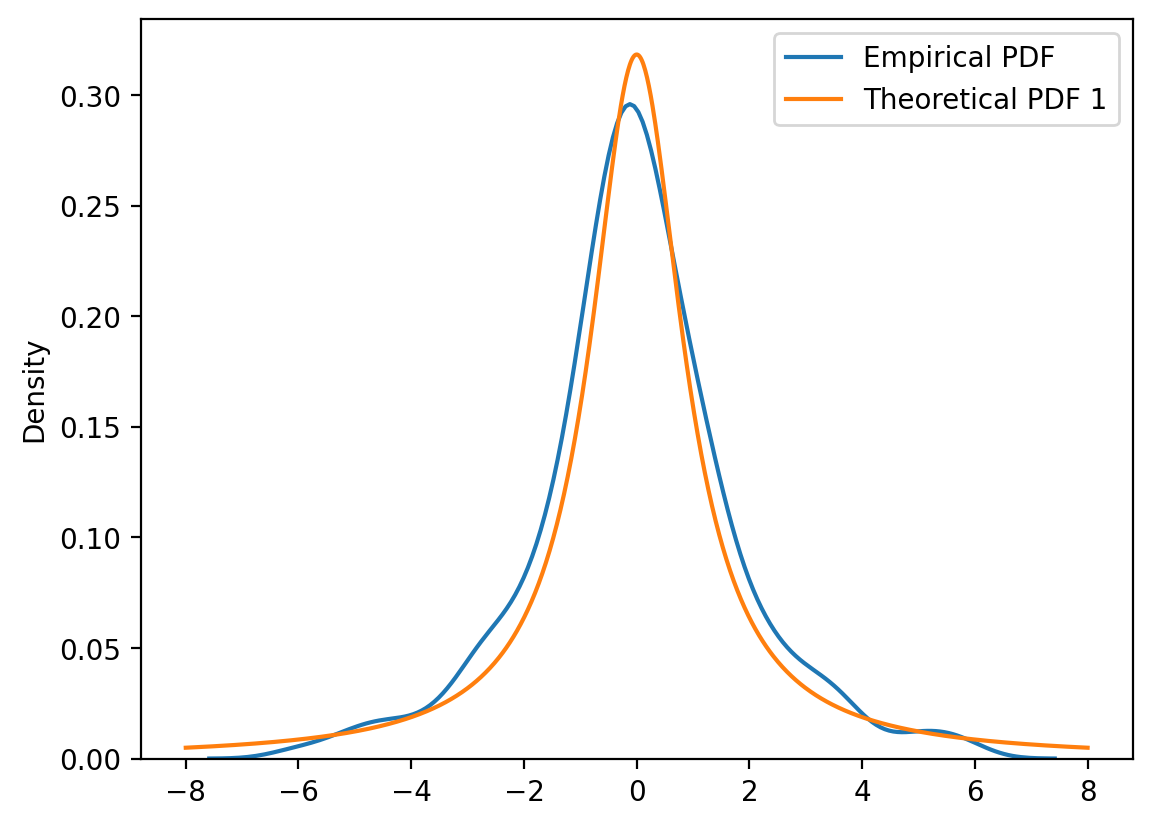

In [ ]:
uniform_samples_1 = uniform.rvs(size=1000) * 0.90 + .05
cauchy_samples = np.tan(np.pi * (uniform_samples_1 - 0.5))

dist = D.Cauchy(loc=0, scale=1)
x = np.linspace(-8, 8, 1000)
x_torch = torch.tensor(x, dtype=torch.float32)
log_probs = dist.log_prob(x_torch)
probs_1 = torch.exp(log_probs).numpy()

sns.kdeplot(cauchy_samples, label="Empirical PDF")
plt.plot(x, probs_1, label="Theoretical PDF 1")
plt.legend()
plt.show()

### (c)

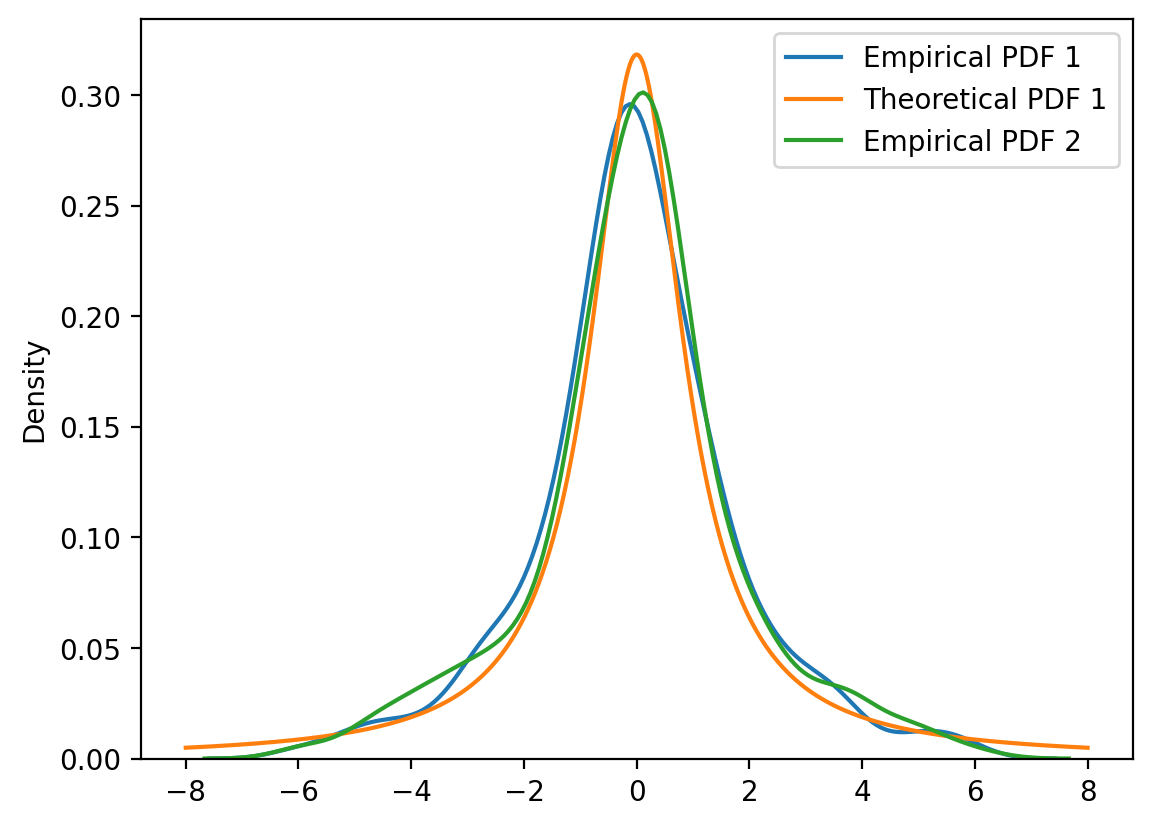

In [ ]:
uniform_samples_2 = uniform.rvs(size=1000) * 0.90 + .05
uniform_tensor = torch.tensor(uniform_samples_2)
theoretical_cauchy_samples = dist.icdf(uniform_tensor)

sns.kdeplot(cauchy_samples, label="Empirical PDF 1")
plt.plot(x, probs_1, label="Theoretical PDF 1")
sns.kdeplot(theoretical_cauchy_samples, label="Empirical PDF 2")
plt.legend()
plt.show()

## 1.3 Rejection Sampling

### (a)

In [ ]:
def target_pdf(x):
    gaussian_pdf = D.Normal(0, 1.5).log_prob(x).exp()
    cauchy_pdf = D.Cauchy(5, 3).log_prob(x).exp()
    return 0.5 * gaussian_pdf + 0.7 * cauchy_pdf

def compute_M(proposal_dist, support: tuple[int, int] = (-15, 15)):
    # Find M by evaluating max(target(x) / proposal(x)) over the support
    x_grid = torch.linspace(support[0], support[1], 1000)
    target_vals = target_pdf(x_grid)
    proposal_vals = torch.exp(proposal_dist.log_prob(x_grid))

    valid_mask = proposal_vals > 0

    M = (target_vals[valid_mask] / proposal_vals[valid_mask]).max().item() * 1.1

    return M

def rejection_sampling(proposal_dist, n_samples: int = 1000, support: tuple[int, int] = (-15, 15)):
    M = compute_M(proposal_dist, support)

    accepted_samples = []
    total_proposals = 0

    while len(accepted_samples) < n_samples:
        proposal_sample = proposal_dist.sample()

        if support[0] < proposal_sample < support[1]:
            total_proposals += 1

            target_density = target_pdf(proposal_sample)
            proposal_density = torch.exp(proposal_dist.log_prob(proposal_sample))

            u = D.Uniform(0, 1).sample()

            if u <= target_density / (M * proposal_density):
                accepted_samples.append(proposal_sample.item())

    acceptance_ratio = len(accepted_samples) / total_proposals

    return accepted_samples, acceptance_ratio

# Run rejection sampling with all three proposal distributions
normal = D.Normal(5, 5)
samples_1, ratio_1 = rejection_sampling(normal)

uniform_ = D.Uniform(-15, 15)
samples_2, ratio_2 = rejection_sampling(uniform_)

laplace = D.Laplace(loc=5, scale=5)
samples_3, ratio_3 = rejection_sampling(laplace)

# Summary
print(f"Uniform(-15, -5): {ratio_1:.4f}")
print(f"Uniform(-15, 15): {ratio_2:.4f}")
print(f"Laplace(loc=5, scale=5): {ratio_3:.4f}")

Uniform(-15, -5): 0.0163
Uniform(-15, 15): 0.2177
Laplace(loc=5, scale=5): 0.2616


### (b)

In [ ]:
def plot_rejection_sampling(proposal_dist, samples, acceptance_ratio, title, support=(-15, 15)):
    M = compute_M(proposal_dist, support)

    x = torch.linspace(support[0], support[1], 1000)

    target_vals = target_pdf(x).numpy()
    proposal_vals = torch.exp(proposal_dist.log_prob(x)).numpy()
    scaled_proposal_vals = M * proposal_vals

    # Chart
    plt.plot(x.numpy(), target_vals, label='Target PDF (unnormalized)')
    plt.plot(x.numpy(), proposal_vals, label='Proposal PDF')
    plt.plot(x.numpy(), scaled_proposal_vals, label=f'Scaled Proposal')
    sns.kdeplot(samples, label='Empirical PDF (accepted samples)')

    plt.ylabel('Density')
    plt.title(title)
    plt.legend()
    plt.xlim(support[0], support[1])
    plt.show()

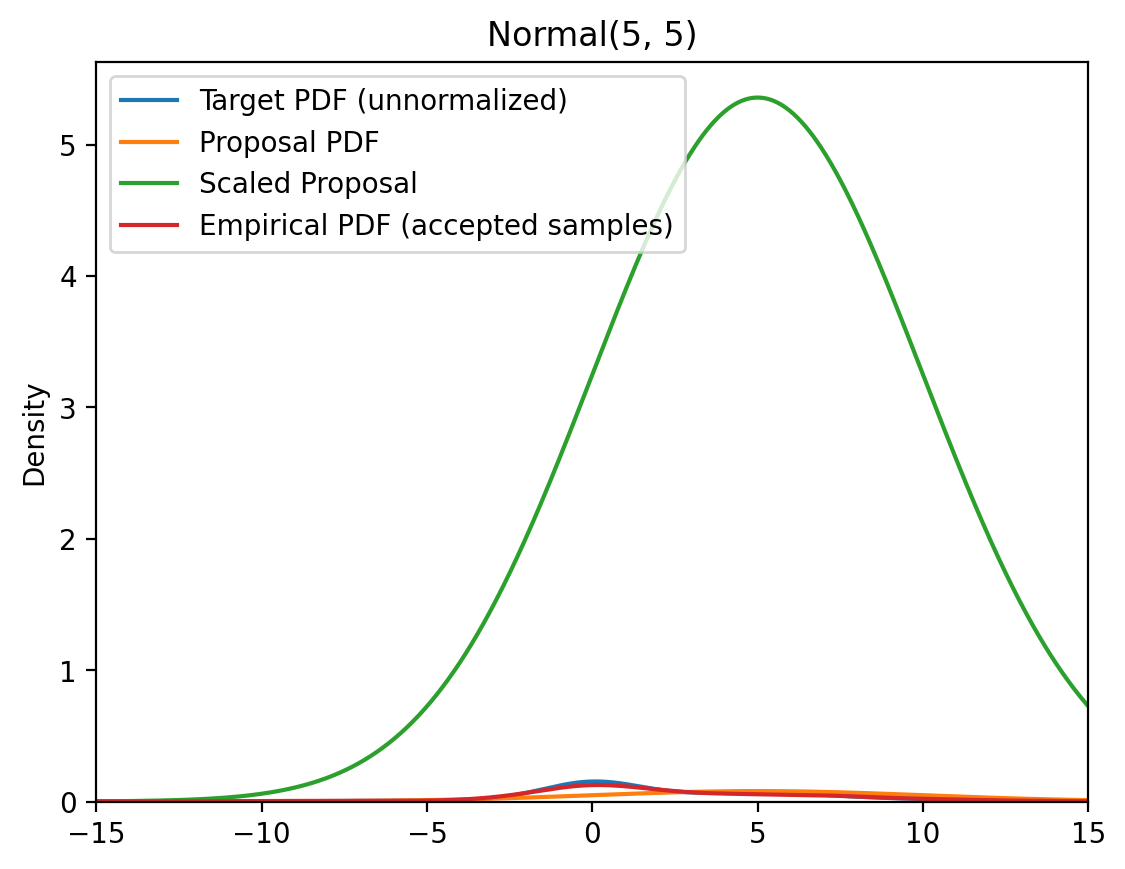

In [ ]:
plot_rejection_sampling(normal, samples_1, ratio_1, 'Normal(5, 5)')

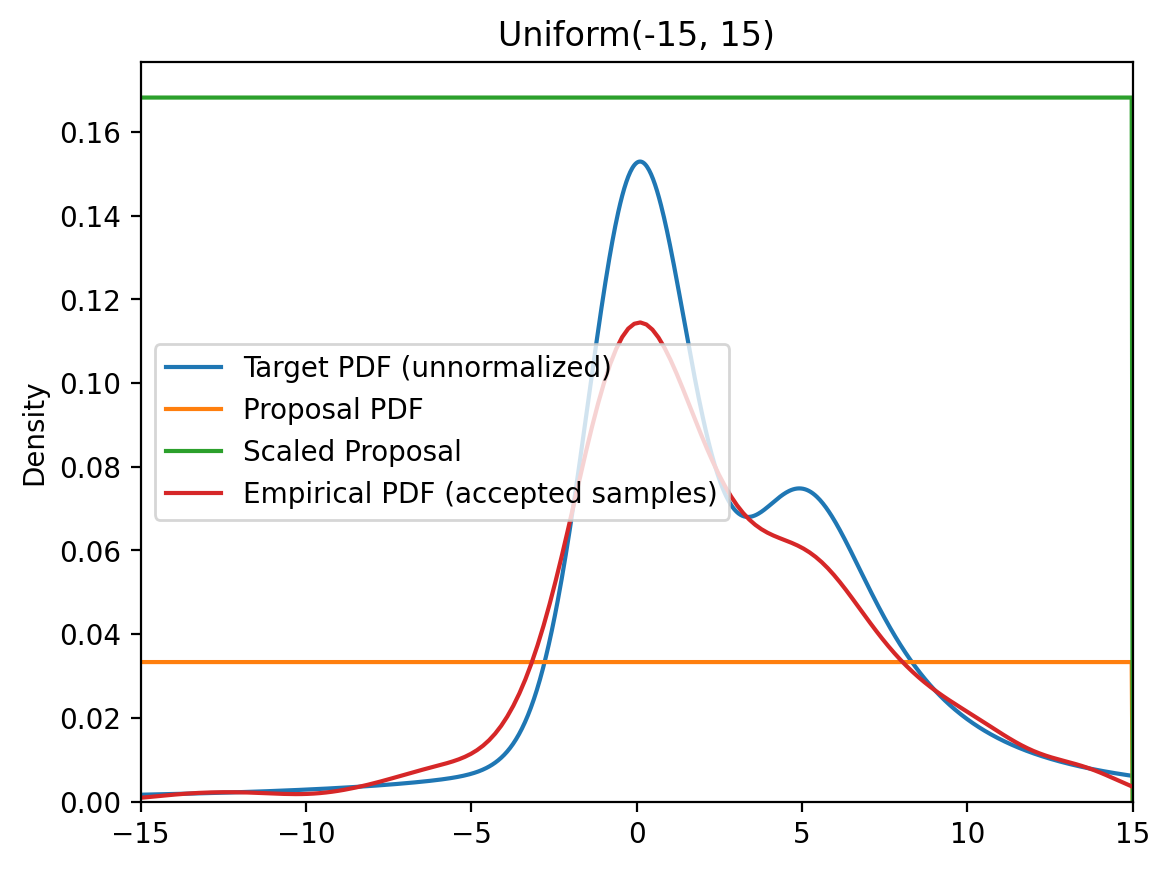

In [ ]:
plot_rejection_sampling(uniform_, samples_2, ratio_2, 'Uniform(-15, 15)')

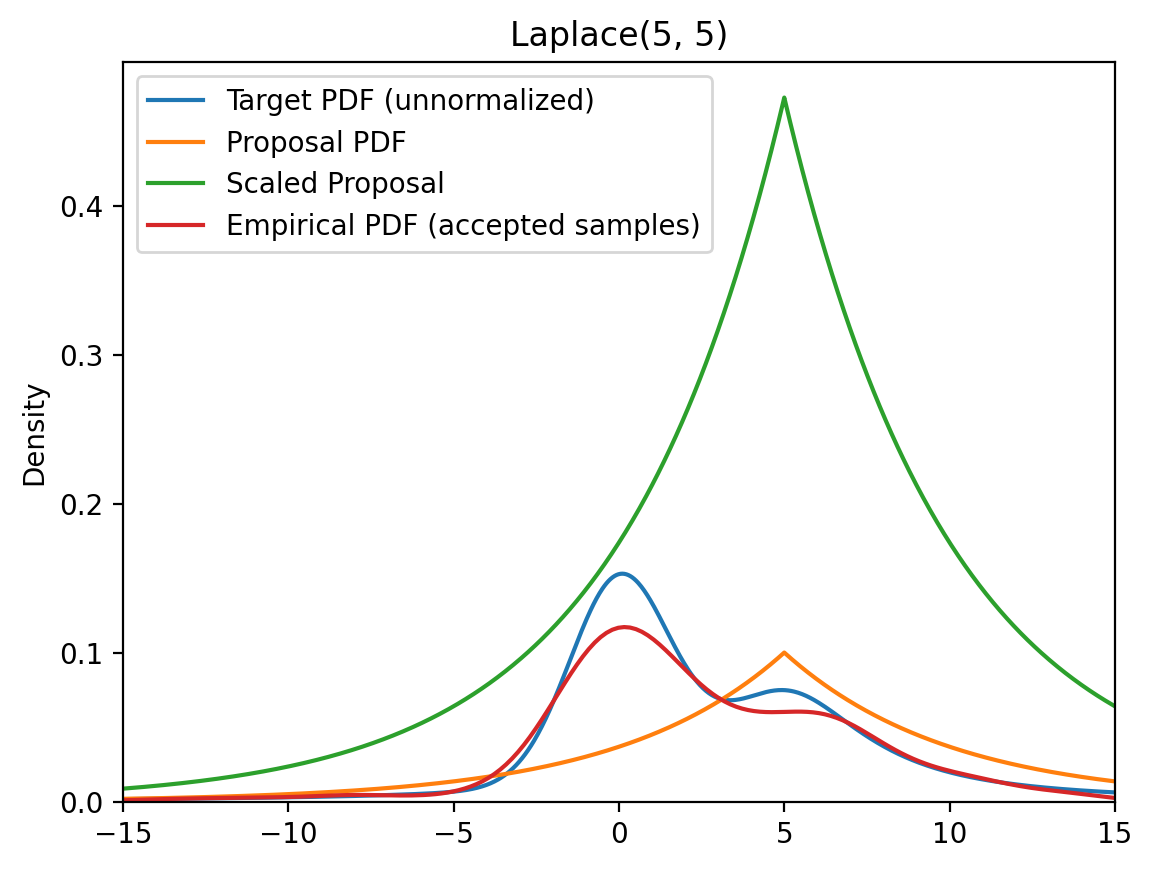

In [ ]:
plot_rejection_sampling(laplace, samples_3, ratio_3, 'Laplace(5, 5)')